# Визуализация результатов SSL-предоубечения (masked reconstruction) полного

## Train vs Val loss

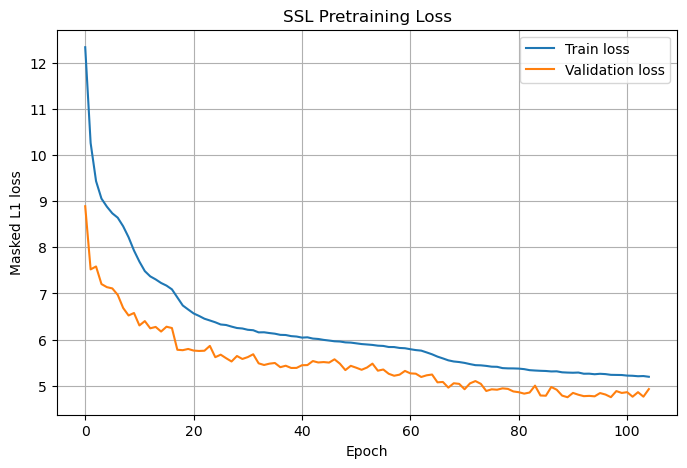

In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

Loss_hystory_path = Path(r'C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\SSL_masked_reconstruction_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\results\ssl_checkpoints\loss_history.json')

with open(Loss_hystory_path) as f:
    hist = json.load(f)

train_loss = hist["train_loss"]
val_loss = hist["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(train_loss, label="Train loss")
plt.plot(val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Masked L1 loss")
plt.title("SSL Pretraining Loss")
plt.legend()
plt.grid(True)

plt.show()

## Пример реконструкции

Показать:
- оригинальный сигнал

- masked сигнал

- реконструкцию

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

In [4]:
val_array_path = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\SSL_masked_reconstruction_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Split\X_val.npy")
encoder_ckpt_path = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\SSL_masked_reconstruction_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\results\ssl_checkpoints\encoder_best.pt")

In [5]:
class SSLNpyDataset(Dataset):
    def __init__(self, npy_path, scale_to_uv=True):
        self.X = np.load(npy_path, mmap_mode="r")
        self.scale_to_uv = scale_to_uv

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)

        if self.scale_to_uv:
            x = x * 1e6

        return torch.from_numpy(x)   # (C, L)

In [6]:
val_dataset = SSLNpyDataset(val_array_path, scale_to_uv=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

In [7]:
def batch_time_block_mask(x, mask_ratio=0.5, block_size=16, generator=None):
    """
    x: (B, C, L)
    returns:
        x_masked: (B, C, L)
        mask: (B, L), where 1 = masked
    """
    assert x.ndim == 3, f"Expected x with shape (B, C, L), got {x.shape}"

    B, C, L = x.shape
    device = x.device

    if block_size > L:
        raise ValueError(f"block_size={block_size} cannot be greater than sequence length L={L}")

    n_mask_target = int(L * mask_ratio)
    mask = torch.zeros(B, L, device=device, dtype=x.dtype)

    for b in range(B):
        masked = 0
        while masked < n_mask_target:
            start = torch.randint(
                low=0,
                high=L - block_size + 1,
                size=(1,),
                device=device,
                generator=generator,
            ).item()

            end = start + block_size

            newly = 1.0 - mask[b, start:end]
            mask[b, start:end] = 1.0
            masked += int(newly.sum().item())

    x_masked = x * (1.0 - mask.unsqueeze(1))
    return x_masked, mask

In [8]:
import torch
import torch.nn as nn

class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet1D_Light(n_channels=14, n_classes=14)  # или как у тебя было при обучении
model = model.to(device)

encoder_state = torch.load(encoder_ckpt_path, map_location=device)

model.inc.load_state_dict(encoder_state["inc"])
model.down1.load_state_dict(encoder_state["down1"])
model.down2.load_state_dict(encoder_state["down2"])
model.down3.load_state_dict(encoder_state["down3"])
model.down4.load_state_dict(encoder_state["down4"])

model.eval()

print("Encoder weights loaded successfully.")

Encoder weights loaded successfully.


In [10]:
full_ckpt_path = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\SSL_masked_reconstruction_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\results\ssl_checkpoints\checkpoint_best_full.pt")

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet1D_Light(n_channels=14, n_classes=14)   # как при обучении
model = model.to(device)

ckpt = torch.load(full_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

model.eval()

print("Full SSL checkpoint loaded successfully.")

Full SSL checkpoint loaded successfully.


In [12]:
x = next(iter(val_loader)).to(device)

g = torch.Generator(device=device)
g.manual_seed(2026)

x_masked, mask = batch_time_block_mask(
    x,
    mask_ratio=0.5,
    block_size=16,
    generator=g,
)

with torch.no_grad():
    recon, z = model(x_masked)

print("x      :", x.shape)
print("masked :", x_masked.shape)
print("recon  :", recon.shape)
print("z      :", z.shape)

x      : torch.Size([16, 14, 208])
masked : torch.Size([16, 14, 208])
recon  : torch.Size([16, 14, 208])
z      : torch.Size([16, 512, 13])


In [17]:
sample_idx = 0
channel_idx = 2 # Pz  

In [14]:
orig = x[sample_idx, channel_idx].detach().cpu().numpy()
masked = x_masked[sample_idx, channel_idx].detach().cpu().numpy()
rec = recon[sample_idx, channel_idx].detach().cpu().numpy()
m = mask[sample_idx].detach().cpu().numpy()

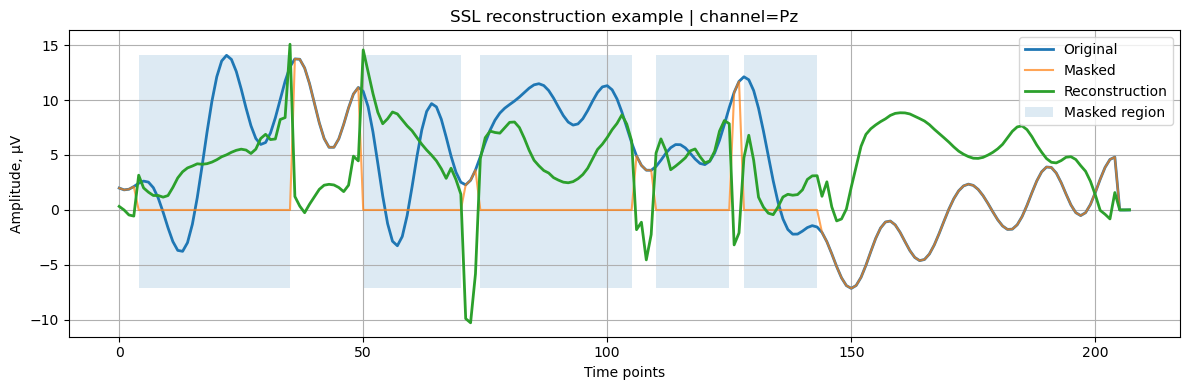

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(orig, label="Original", linewidth=2)
plt.plot(masked, label="Masked", alpha=0.7)
plt.plot(rec, label="Reconstruction", linewidth=2)

plt.fill_between(
    np.arange(len(m)),
    orig.min(),
    orig.max(),
    where=(m == 1),
    alpha=0.15,
    label="Masked region"
)

plt.xlabel("Time points")
plt.ylabel("Amplitude, µV")
plt.title(f"SSL reconstruction example | channel=Pz")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

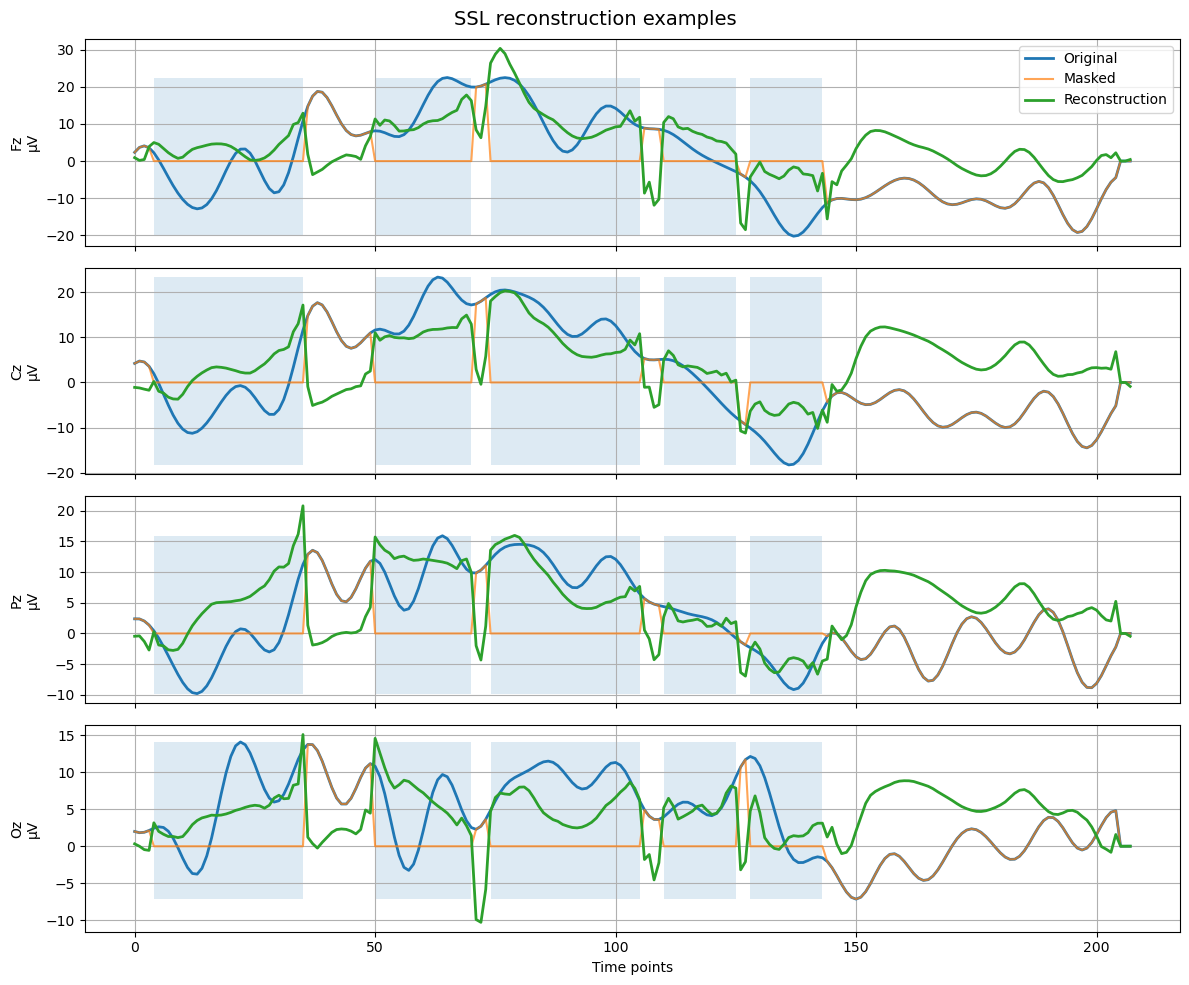

In [16]:
channel_names = ["Fz", "Cz", "Pz", "Oz"]
channel_indices = [0, 1, 2, 3]

sample_idx = 0

fig, axes = plt.subplots(len(channel_indices), 1, figsize=(12, 10), sharex=True)

for ax, ch_idx, ch_name in zip(axes, channel_indices, channel_names):
    orig = x[sample_idx, ch_idx].detach().cpu().numpy()
    masked = x_masked[sample_idx, ch_idx].detach().cpu().numpy()
    rec = recon[sample_idx, ch_idx].detach().cpu().numpy()
    m = mask[sample_idx].detach().cpu().numpy()

    ax.plot(orig, label="Original", linewidth=2)
    ax.plot(masked, label="Masked", alpha=0.7)
    ax.plot(rec, label="Reconstruction", linewidth=2)

    ax.fill_between(
        np.arange(len(m)),
        orig.min(),
        orig.max(),
        where=(m == 1),
        alpha=0.15,
    )

    ax.set_ylabel(f"{ch_name}\nµV")
    ax.grid(True)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time points")
fig.suptitle("SSL reconstruction examples", fontsize=14)
plt.tight_layout()
plt.show()